# 03 — Tuning Results & Final Model Comparison

**Mục tiêu:**
1. Hiển thị kết quả Hyperparameter Tuning (Optuna) cho 5 mô hình (RF, LR, KNN, SVM, Neural Network)
2. So sánh F1 / Recall / Precision sau khi tuning (chỉ SMOTE)
3. Đề xuất mô hình tốt nhất


In [1]:
import sys
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import REPORTS_DIR, MODELS_DIR, MODEL_NAMES
from src.models import get_model_display_name
from src.keras_nn import KerasNN

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

## 1. Load Tuning Results (Best Params)

> **Lưu ý:** Chỉ có kết quả tuning với SMOTE được hiển thị. Baseline không tham gia tuning.

In [2]:
tuning_results = []

for name in MODEL_NAMES:
    params_file = REPORTS_DIR / f'best_params_{name}.json'
    if params_file.exists():
        with open(params_file) as f:
            data = json.load(f)
        print(f'\n✅ {get_model_display_name(name)}:')
        print(f'   Best F1: {data["best_f1"]:.4f}')
        print(f'   Params:  {json.dumps(data["params"], indent=2)}')
        tuning_results.append({
            'Model': get_model_display_name(name),
            'Best CV F1': data['best_f1'],
            'Best Params': json.dumps(data['params']),
        })
    else:
        print(f'\n❌ {get_model_display_name(name)}: No tuning results found')
        print(f'   Run: python run_pipeline.py --step tune --models {name[:2]}')

if tuning_results:
    tuning_df = pd.DataFrame(tuning_results)
    print('\n' + '='*60)
    print(tuning_df[['Model', 'Best CV F1']].to_string(index=False))


✅ Random Forest:
   Best F1: 0.9999
   Params:  {
  "n_estimators": 150,
  "max_depth": 30,
  "min_samples_split": 4,
  "class_weight": "balanced"
}

✅ Logistic Regression:
   Best F1: 0.9526
   Params:  {
  "C": 21.368329072358762,
  "l1_ratio": 0.21233911067827616,
  "class_weight": null
}

✅ K-Nearest Neighbors:
   Best F1: 0.9972
   Params:  {
  "n_neighbors": 3,
  "weights": "distance",
  "metric": "manhattan"
}

✅ Support Vector Machine:
   Best F1: 0.9982
   Params:  {
  "C": 42.741460350167124,
  "gamma": "auto",
  "class_weight": null
}

✅ Neural Network (Keras):
   Best F1: 0.9994
   Params:  {
  "n_layers": 4,
  "layer_0_units": 48,
  "layer_1_units": 24,
  "layer_2_units": 48,
  "layer_3_units": 16,
  "dropout": 0.11967800821618821,
  "lr": 0.0018919518068619323,
  "epochs": 33,
  "batch_size": 512,
  "activation": "relu"
}

                 Model  Best CV F1
         Random Forest    0.999886
   Logistic Regression    0.952551
   K-Nearest Neighbors    0.997184
Support Ve

## 2. Load Training & Evaluation Results (SMOTE only)

In [4]:
# Load results — try both naming conventions
smote_file = REPORTS_DIR / 'all_models_smote.csv'
comparison_smote = list(REPORTS_DIR.glob('model_comparison_smote*.csv'))

if smote_file.exists():
    results_df = pd.read_csv(smote_file)
    # Thêm cột sampling nếu chưa có
    if 'sampling' not in results_df.columns:
        results_df['sampling'] = 'SMOTE'
    # Đổi tên cột Model → model cho thống nhất
    if 'Model' in results_df.columns:
        results_df.rename(columns={'Model': 'model'}, inplace=True)
    print('📊 Results (SMOTE — from all_models_smote.csv):')
    print(results_df.to_string(index=False))

elif comparison_smote:
    results_df = pd.read_csv(comparison_smote[0])
    print('📊 Results (SMOTE — from model_comparison):')
    print(results_df.to_string(index=False))

else:
    print('\n⚠️ No SMOTE results found. Run the training pipeline first.')
    results_df = pd.DataFrame()


📊 Results (SMOTE — from all_models_smote.csv):
                 model  accuracy  precision  recall  f1_score  auc_roc  auc_pr sampling
         Random Forest    0.9995     0.8632  0.8367    0.8497   0.9731  0.8696    SMOTE
   Logistic Regression    0.9747     0.0591  0.9184    0.1110   0.9713  0.7222    SMOTE
   K-Nearest Neighbors    0.9978     0.4300  0.8776    0.5772   0.9535  0.6102    SMOTE
Support Vector Machine    0.9848     0.0918  0.8776    0.1662   0.9642  0.6080    SMOTE
Neural Network (Keras)    0.9988     0.6148  0.8469    0.7124   0.9595  0.8055    SMOTE


## 3. Visualisation — Model Performance Comparison (SMOTE)

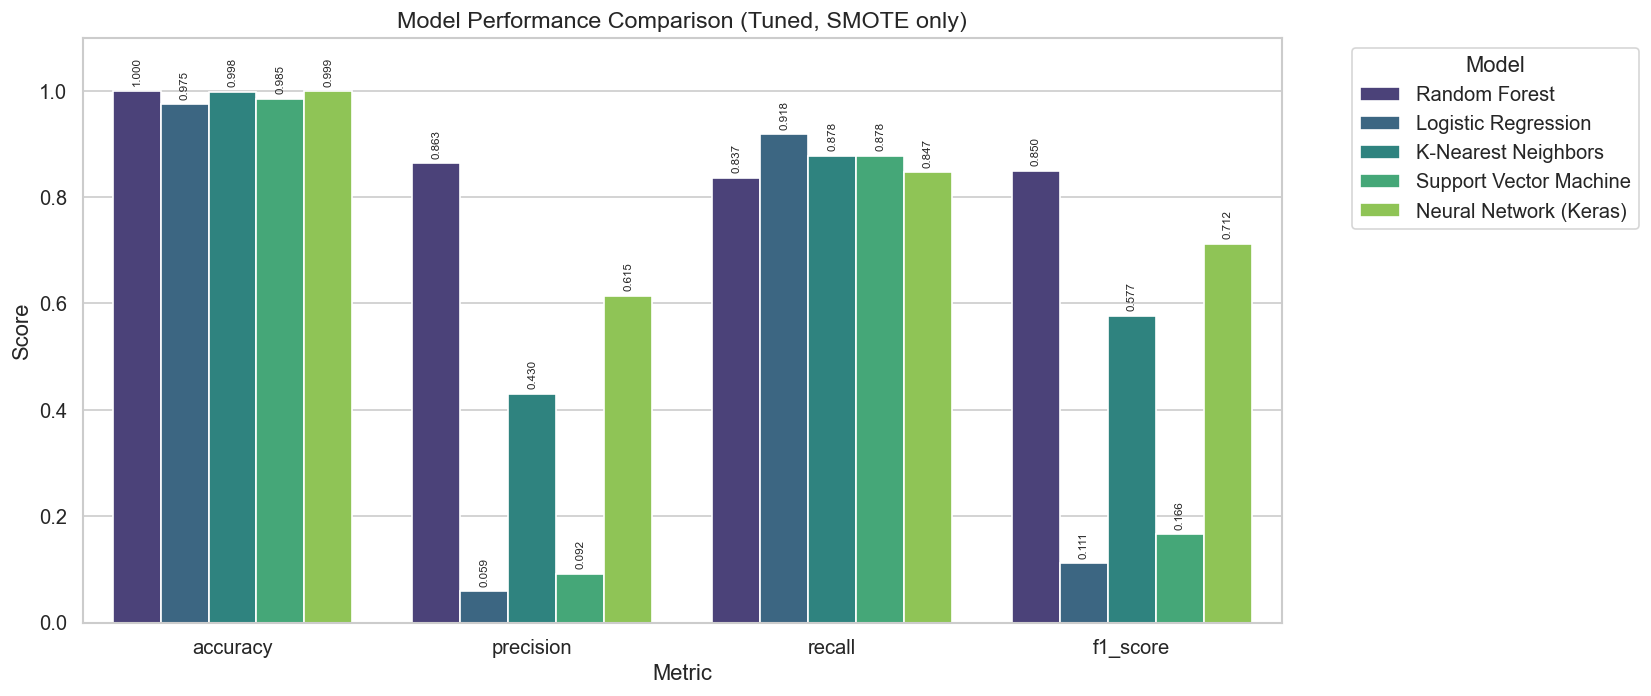

In [5]:
if not results_df.empty:
    metrics_cols = ['accuracy', 'precision', 'recall', 'f1_score']
    available_metrics = [m for m in metrics_cols if m in results_df.columns]
    
    # Grouped bar chart
    melted = results_df.melt(
        id_vars=['model', 'sampling'], 
        value_vars=available_metrics,
        var_name='Metric', value_name='Score'
    )
    
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=melted, x='Metric', y='Score', hue='model', ax=ax,
                palette='viridis')
    ax.set_title('Model Performance Comparison (Tuned, SMOTE only)', fontsize=14)
    ax.set_ylim([0, 1.1])
    ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=7, rotation=90, padding=3)
    
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / 'tuning_model_comparison.png'))
    plt.show()
else:
    print('No results to plot.')

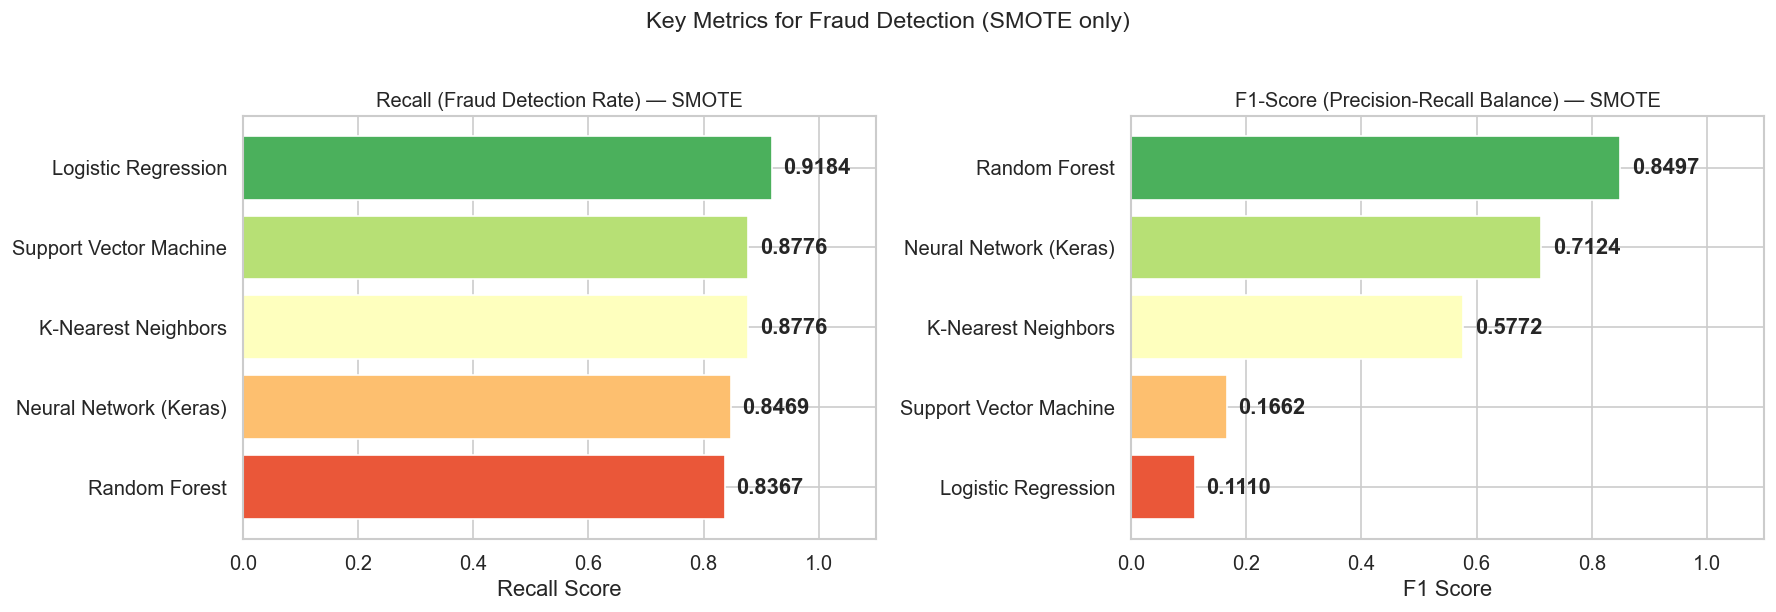

In [6]:
# Focus on Recall and F1 (the most important metrics for fraud detection)
if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Recall comparison
    if 'recall' in results_df.columns:
        recall_sorted = results_df.sort_values('recall', ascending=True)
        colors = sns.color_palette('RdYlGn', len(recall_sorted))
        axes[0].barh(recall_sorted['model'], recall_sorted['recall'], color=colors)
        axes[0].set_title('Recall (Fraud Detection Rate) — SMOTE', fontsize=12)
        axes[0].set_xlabel('Recall Score')
        axes[0].set_xlim([0, 1.1])
        for i, (v, name) in enumerate(zip(recall_sorted['recall'], recall_sorted['model'])):
            axes[0].text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold')
    
    # F1 comparison
    if 'f1_score' in results_df.columns:
        f1_sorted = results_df.sort_values('f1_score', ascending=True)
        colors = sns.color_palette('RdYlGn', len(f1_sorted))
        axes[1].barh(f1_sorted['model'], f1_sorted['f1_score'], color=colors)
        axes[1].set_title('F1-Score (Precision-Recall Balance) — SMOTE', fontsize=12)
        axes[1].set_xlabel('F1 Score')
        axes[1].set_xlim([0, 1.1])
        for i, (v, name) in enumerate(zip(f1_sorted['f1_score'], f1_sorted['model'])):
            axes[1].text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold')
    
    plt.suptitle('Key Metrics for Fraud Detection (SMOTE only)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / 'tuning_recall_f1_comparison.png'))
    plt.show()

## 4. ROC-AUC & AUC-PR Comparison (SMOTE)

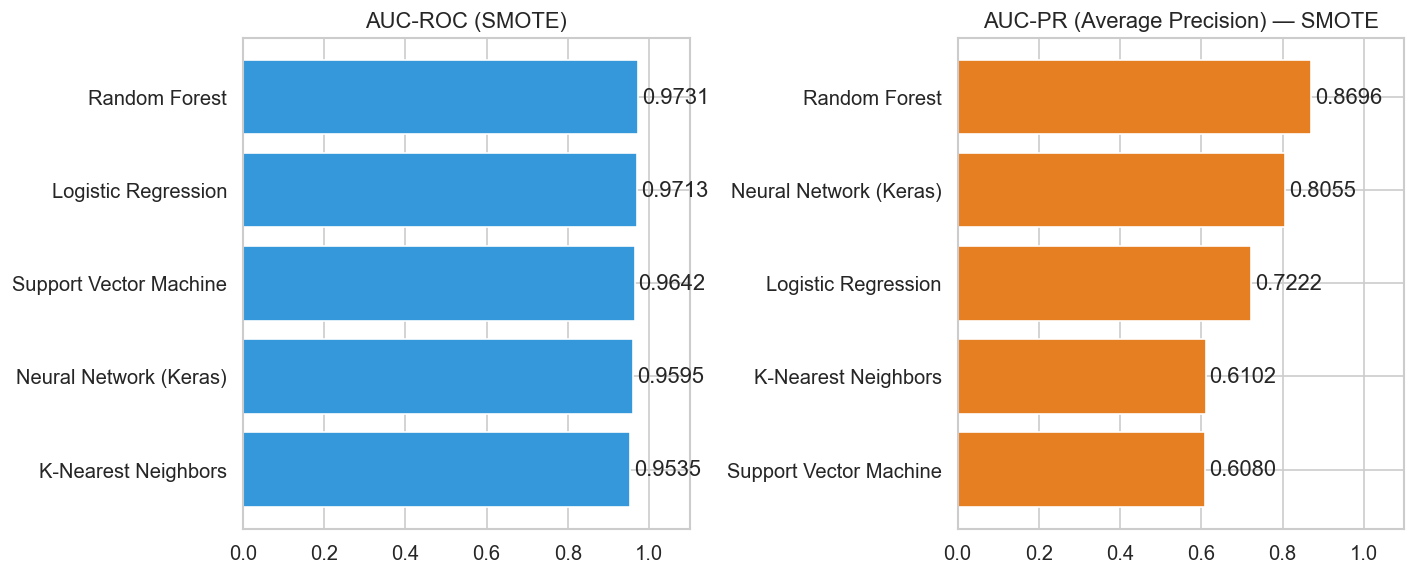

In [7]:
if not results_df.empty and 'auc_roc' in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # AUC-ROC
    sorted_roc = results_df.sort_values('auc_roc', ascending=True)
    axes[0].barh(sorted_roc['model'], sorted_roc['auc_roc'], color='#3498db')
    axes[0].set_title('AUC-ROC (SMOTE)')
    axes[0].set_xlim([0, 1.1])
    for i, v in enumerate(sorted_roc['auc_roc']):
        axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')
    
    # AUC-PR
    if 'auc_pr' in results_df.columns:
        sorted_pr = results_df.sort_values('auc_pr', ascending=True)
        axes[1].barh(sorted_pr['model'], sorted_pr['auc_pr'], color='#e67e22')
        axes[1].set_title('AUC-PR (Average Precision) — SMOTE')
        axes[1].set_xlim([0, 1.1])
        for i, v in enumerate(sorted_pr['auc_pr']):
            axes[1].text(v + 0.01, i, f'{v:.4f}', va='center')
    
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / 'tuning_auc_comparison.png'))
    plt.show()
else:
    print('AUC metrics not available.')

## 5. Feature Importance (Random Forest — SMOTE)

/var/folders/07/2c6q616j2nvbtfhnr3ldwms80000gn/T/ipykernel_31042/2090221607.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x='importance', y='feature', ax=ax, palette='viridis')


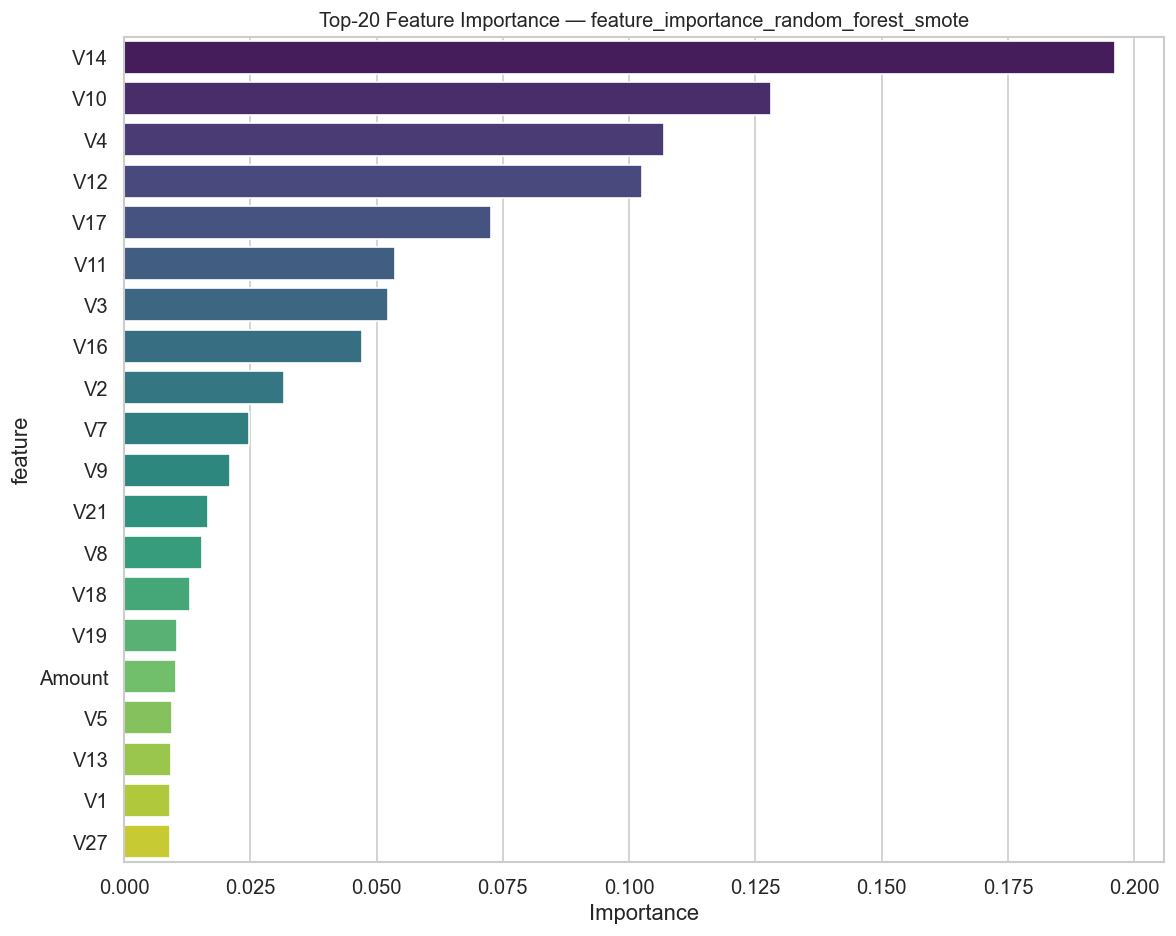

In [8]:
fi_files = list(REPORTS_DIR.glob('feature_importance_*.csv'))

if fi_files:
    fi_df = pd.read_csv(fi_files[0])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = fi_df.head(20)
    sns.barplot(data=top20, x='importance', y='feature', ax=ax, palette='viridis')
    ax.set_title(f'Top-20 Feature Importance — {fi_files[0].stem}', fontsize=12)
    ax.set_xlabel('Importance')
    
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / 'tuning_feature_importance_top20.png'))
    plt.show()
else:
    print('No feature importance files found.')

## 6. 🏆 Best Model Recommendation (SMOTE only)

> **Chỉ xét các mô hình đã huấn luyện với SMOTE.** Baseline bị loại khỏi đánh giá do dữ liệu mất cân bằng cực đoan (0.173% fraud) khiến các chỉ số accuracy bị ảo.

In [9]:
if not results_df.empty and 'f1_score' in results_df.columns:
    # Already filtered to exclude baseline (done in section 2)
    filtered_df = results_df.copy()
    
    # Rank by F1 (primary) and Recall (secondary)
    ranked = filtered_df.sort_values(['f1_score', 'recall'], ascending=False).reset_index(drop=True)
    ranked.index = ranked.index + 1  # 1-indexed rank
    ranked.index.name = 'Rank'
    
    print('\n MODEL RANKING (by F1-Score → Recall):')
    print('=' * 70)
    print(ranked.to_string())
    print('=' * 70)
    
    best = ranked.iloc[0]
    print(f'\n🥇 BEST MODEL: {best["model"]}')
    print(f'   Sampling:  {best["sampling"]}')
    print(f'   F1-Score:  {best["f1_score"]:.4f}')
    print(f'   Recall:    {best["recall"]:.4f}')
    print(f'   Precision: {best["precision"]:.4f}')
    if 'auc_roc' in best:
        print(f'   AUC-ROC:   {best["auc_roc"]:.4f}')
    
    # Save final ranking
    ranked.to_csv(REPORTS_DIR / 'final_model_ranking.csv')
    print('\n✅ Saved ranking → reports/final_model_ranking.csv')
else:
    print('No results to rank. Run the pipeline first.')


 MODEL RANKING (by F1-Score → Recall):
                       model  accuracy  precision  recall  f1_score  auc_roc  auc_pr sampling
Rank                                                                                         
1              Random Forest    0.9995     0.8632  0.8367    0.8497   0.9731  0.8696    SMOTE
2     Neural Network (Keras)    0.9988     0.6148  0.8469    0.7124   0.9595  0.8055    SMOTE
3        K-Nearest Neighbors    0.9978     0.4300  0.8776    0.5772   0.9535  0.6102    SMOTE
4     Support Vector Machine    0.9848     0.0918  0.8776    0.1662   0.9642  0.6080    SMOTE
5        Logistic Regression    0.9747     0.0591  0.9184    0.1110   0.9713  0.7222    SMOTE

🥇 BEST MODEL: Random Forest
   Sampling:  SMOTE
   F1-Score:  0.8497
   Recall:    0.8367
   Precision: 0.8632
   AUC-ROC:   0.9731

✅ Saved ranking → reports/final_model_ranking.csv


## 7. Saved Model Artifacts

In [10]:
print('📁 Saved model files:')
for pkl_file in sorted(MODELS_DIR.glob('*.pkl')):
    size_mb = pkl_file.stat().st_size / 1e6
    print(f'  → {pkl_file.name:40s} ({size_mb:.1f} MB)')

print(f'\n📁 Report files:')
for report_file in sorted(REPORTS_DIR.glob('*')):
    size_mb = report_file.stat().st_size / 1e6
    print(f'  → {report_file.name:40s} ({size_mb:.2f} MB)')

📁 Saved model files:
  → knn_smote.pkl                            (22.6 MB)
  → logistic_regression_smote.pkl            (0.0 MB)
  → neural_network_smote.pkl                 (0.1 MB)
  → random_forest_smote.pkl                  (24.2 MB)
  → robust_scaler.pkl                        (0.0 MB)
  → svm_smote.pkl                            (0.4 MB)

📁 Report files:
  → all_models_3x4_confusion_matrices.png    (0.36 MB)
  → all_models_baseline.csv                  (0.00 MB)
  → all_models_smote.csv                     (0.00 MB)
  → all_models_under_sampling.csv            (0.00 MB)
  → best_params_knn.json                     (0.00 MB)
  → best_params_logistic_regression.json     (0.00 MB)
  → best_params_neural_network.json          (0.00 MB)
  → best_params_random_forest.json           (0.00 MB)
  → best_params_svm.json                     (0.00 MB)
  → cm_knn_baseline.png                      (0.03 MB)
  → cm_knn_smote.png                         (0.03 MB)
  → cm_knn_smote_default.png   

---

**Kết quả:**
- Best params cho từng mô hình → `reports/best_params_*.json`
- Model comparison → `reports/model_comparison_*.csv` (SMOTE only)
- Final ranking → `reports/final_model_ranking.csv`
- Saved models → `models/*_smote.pkl` (chỉ SMOTE)